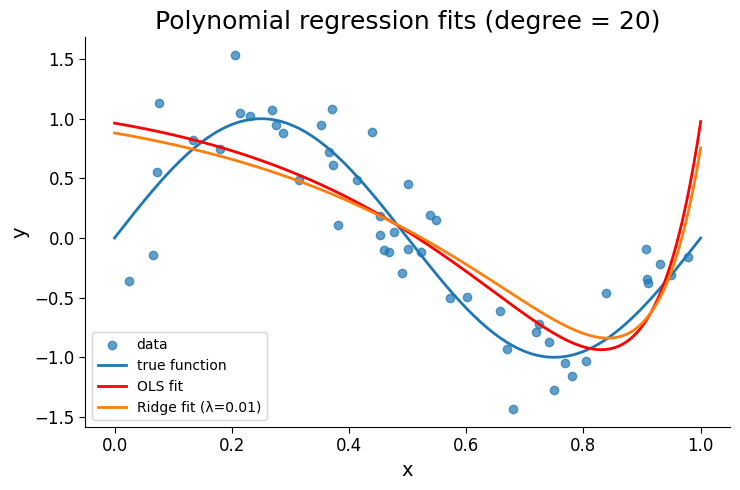

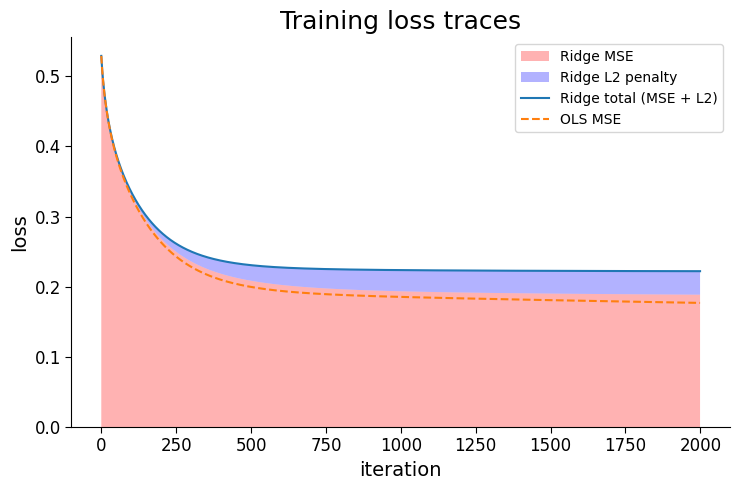

{'OLS_final_MSE': 0.17691837232743363,
 'Ridge_final_MSE': 0.18862690374130792,
 'Ridge_final_L2': 0.03349643294611312,
 'Ridge_final_total': 0.22212333668742104,
 'Check_sum(MSE+L2)': 0.22212333668742104}

In [1]:

# Polynomial regression with and without L2 regularization
# - Shows fitted curves
# - Shows training loss traces (MSE vs MSE+L2 with stacked breakdown)
#
# Notes:
# * Intercept is NOT penalized.
# * Uses plain gradient descent so the traces are meaningful.
# * Matplotlib only (no seaborn), one chart per figure, no manual colors.

from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Dict
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "paper").exists():
    ROOT = ROOT.parent
PAPER_FIGURES_DIR = ROOT / "paper" / "figures"
PAPER_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

style_path = ROOT / "clean_fig.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


def save_paper_figure(
    fig: plt.Figure,
    filename: str,
    *,
    dpi: int = 300,
    bbox_inches: str | None = "tight",
):
    out_path = PAPER_FIGURES_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches=bbox_inches)
    print(out_path)
    return out_path

np.random.seed(7)


def make_data(n: int = 30, noise: float = 0.12) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate x in [0,1], true y = sin(2πx), add Gaussian noise."""
    x = np.sort(np.random.rand(n))
    y_true = np.sin(2 * np.pi * x)
    y = y_true + noise * np.random.randn(n)
    return x, y_true, y


def poly_features(x: np.ndarray, degree: int) -> np.ndarray:
    """Return Vandermonde-style polynomial features with intercept as column 0.
    We map x to [-1, 1] for numeric stability.
    """
    # x_scaled = 2 * x - 1.0
    X = np.vstack([x ** k for k in range(degree + 1)]).T
    return X


@dataclass
class GDResult:
    w: np.ndarray
    mse_trace: np.ndarray
    l2_trace: np.ndarray
    obj_trace: np.ndarray


def train_gd(
    X: np.ndarray, y: np.ndarray, lam: float, lr: float, iters: int
) -> GDResult:
    """Train polynomial regression by gradient descent with L2 (ridge) penalty.
    Intercept (w[0]) is not penalized.
    """
    n, d = X.shape
    w = np.zeros(d)
    mse_trace, l2_trace, obj_trace = [], [], []

    # mask to avoid penalizing intercept
    reg_mask = np.ones_like(w)
    reg_mask[0] = 0.0

    for _ in range(iters):
        yhat = X @ w
        resid = yhat - y
        mse = np.mean(resid ** 2)
        l2 = lam * np.sum((reg_mask * w) ** 2)
        obj = mse + l2

        mse_trace.append(mse)
        l2_trace.append(l2)
        obj_trace.append(obj)

        # gradient: d/dw (MSE) = 2/n X^T (Xw - y), d/dw (L2) = 2λ w (except intercept)
        grad = (2.0 / n) * (X.T @ resid) + 2.0 * lam * (reg_mask * w)
        w = w - lr * grad

    return GDResult(
        w=w,
        mse_trace=np.asarray(mse_trace),
        l2_trace=np.asarray(l2_trace),
        obj_trace=np.asarray(obj_trace),
    )


# ---- Simulation parameters ----
degree = 20
n = 50
noise = 0.3
iters = 2000
lr = 0.03
lam = 1e-2
# ---- Generate data and features ----
x, y_true, y = make_data(n=n, noise=noise)
X = poly_features(x, degree=degree)

# ---- Train: OLS (λ=0) and Ridge (λ>0) ----
ols = train_gd(X, y, lam=0.0, lr=lr, iters=iters)
ridge = train_gd(X, y, lam=lam, lr=lr, iters=iters)

# ---- Plot: fitted curves ----
xs = np.linspace(0, 1, 500)
Xs = poly_features(xs, degree=degree)

yhat_ols = Xs @ ols.w
yhat_ridge = Xs @ ridge.w

plt.figure(figsize=(7.5, 5))
plt.scatter(x, y, label="data", alpha=0.7)
plt.plot(xs, np.sin(2 * np.pi * xs), label="true function", linewidth=2)
plt.plot(xs, yhat_ols, label="OLS fit", color='red', linewidth=2)
plt.plot(xs, yhat_ridge, label=f"Ridge fit (λ={lam:g})", linewidth=2)
plt.title("Polynomial regression fits (degree = {})".format(degree))
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot: training loss traces ----
t = np.arange(iters)

plt.figure(figsize=(7.5, 5))
# Stacked area for Ridge: MSE and L2 components
plt.stackplot(t, ridge.mse_trace, ridge.l2_trace, labels=["Ridge MSE", "Ridge L2 penalty"], colors=["red", "blue"], alpha=0.3)
# Overlay total objective for Ridge
plt.plot(t, ridge.obj_trace, label="Ridge total (MSE + L2)", linewidth=1.5)
# Overlay OLS MSE
plt.plot(t, ols.mse_trace, label="OLS MSE", linewidth=1.5, linestyle="--")
plt.title("Training loss traces")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ---- Print final metrics to highlight decomposition ----
final_info = {
    "OLS_final_MSE": float(ols.mse_trace[-1]),
    "Ridge_final_MSE": float(ridge.mse_trace[-1]),
    "Ridge_final_L2": float(ridge.l2_trace[-1]),
    "Ridge_final_total": float(ridge.obj_trace[-1]),
    "Check_sum(MSE+L2)": float(ridge.mse_trace[-1] + ridge.l2_trace[-1]),
}
final_info

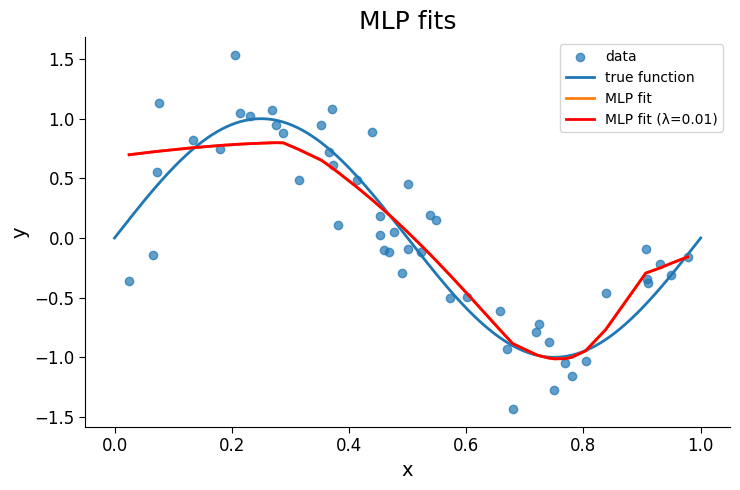

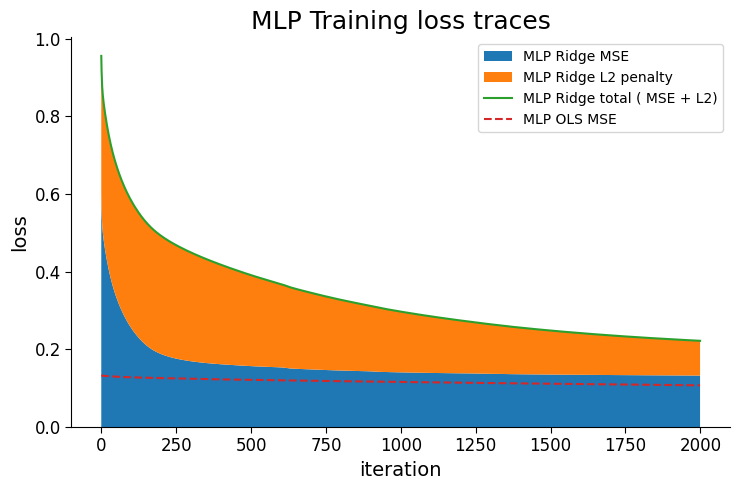

In [2]:
# Train an MLP on the same data for comparison
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(7)
import torch.nn.functional as F

# --- IGNORE ---
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# training loop tracking both empirical loss and L2 penalty
def train_mlp(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    lam: float,
    lr: float,
    iters: int,
) -> Tuple[nn.Module, np.ndarray, np.ndarray, np.ndarray]:
    mse_trace, l2_trace, obj_trace = [], [], []
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for _ in range(iters):
        model.train()
        optimizer.zero_grad()
        yhat = model(X).squeeze()
        mse = criterion(yhat, y)
        l2 = lam * sum((p ** 2).sum() for p in model.parameters())
        obj = mse + l2

        mse_trace.append(mse.item())
        l2_trace.append(l2.item())
        obj_trace.append(obj.item())
        obj.backward()
        optimizer.step()
    return model, np.asarray(mse_trace), np.asarray(l2_trace), np.asarray(obj_trace)


# ---- Train MLP ----
# X_torch = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)
mlp = MLP(input_dim=degree+1, hidden_dim=100, output_dim=1)
mlp_reg, mlp_reg_mse_trace, mlp_reg_l2_trace, mlp_reg_obj_trace = train_mlp(
    mlp, X_torch, y_torch, lam=lam, lr=0.03, iters=iters
)
# without regularization now
mlp, mlp_mse_trace, mlp_l2_trace, mlp_obj_trace = train_mlp(
    mlp, X_torch, y_torch, lam=0.0, lr=0.03, iters=iters
)


# ---- Plot: MLP fitted curve ----
yhat_mlp = mlp(X_torch).detach().numpy().squeeze()
yhat_mlp_reg = mlp_reg(X_torch).detach().numpy().squeeze()
plt.figure(figsize=(7.5, 5))
plt.scatter(x, y, label="data", alpha=0.7)
plt.plot(xs, np.sin(2 * np.pi * xs), label="true function", linewidth=2)
plt.plot(x, yhat_mlp, label="MLP fit", linewidth=2)
plt.plot(x, yhat_mlp_reg, label=f"MLP fit (λ={lam:g})", color='red', linewidth=2)
plt.title("MLP fits")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot: MLP training loss traces ----
t = np.arange(iters)
plt.figure(figsize=(7.5, 5))
# Stacked area for Ridge: MSE and L2 components
plt.stackplot(t, mlp_reg_mse_trace, mlp_reg_l2_trace, labels=["MLP Ridge MSE", "MLP Ridge L2 penalty"])
# Overlay total objective for Ridge
plt.plot(t, mlp_reg_obj_trace, label="MLP Ridge total ( MSE + L2)", linewidth=1.5)
# Overlay OLS MSE
plt.plot(t, mlp_mse_trace, label="MLP OLS MSE", linewidth=1.5, linestyle="--")
plt.title("MLP Training loss traces")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
# Generalizable 3D visualization with modular objectives (using callables/partials)
# - Components are functions w -> scalar; we pass them in a list and visualize:
#   * total surface = sum of components
#   * wireframe for the "data-fit" component (first in list)
#   * contour & projected contour for the "penalty" component (second in list)
# - Intercepts not relevant here; just a 2D parameter space demo.
#
# One figure; matplotlib only; no explicit colors.

from __future__ import annotations
from typing import Callable, Tuple, List, Dict
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from functools import partial

PLOT_FLOOR = -30.0

Vec2 = Tuple[float, float]
Grid = Tuple[np.ndarray, np.ndarray]


def eval_on_grid(
    component: Callable[[np.ndarray, np.ndarray], np.ndarray],
    W1: np.ndarray,
    W2: np.ndarray,
) -> np.ndarray:
    return component(W1, W2)


# --- Example component factories ------------------------------------------------


def quad_mse(
    center: Vec2 = (1.0, 1.0), scale: float = 0.5
) -> Callable[[np.ndarray, np.ndarray], np.ndarray]:
    cx, cy = center

    def f(W1: np.ndarray, W2: np.ndarray) -> np.ndarray:
        return scale * ((W1 - cx) ** 2 + (W2 - cy) ** 2)

    return f


def l2_penalty(lam: float = 0.3) -> Callable[[np.ndarray, np.ndarray], np.ndarray]:
    def f(W1: np.ndarray, W2: np.ndarray) -> np.ndarray:
        return lam * (W1**2 + W2**2)

    return f


def ridge_minimizer_2d(
    lam: float, mse_scale: float = 0.5, mse_center: Vec2 = (1.0, 1.0)
) -> Vec2:
    # Minimizer for mse_scale*((w-c)^2) + lam*||w||^2 with isotropic pieces:
    # (mse_scale + lam*2) w = mse_scale * c  ->  w* = alpha * c, alpha = mse_scale / (mse_scale + 2*lam)
    cx, cy = mse_center
    alpha = mse_scale / (mse_scale + 2.0 * lam)
    return alpha * cx, alpha * cy


# --- Compose components ---------------------------------------------------------

mse_center = (2.0, 3.0)
mse_scale = 1.0
lam = 1.5

components: List[Callable[[np.ndarray, np.ndarray], np.ndarray]] = [
    quad_mse(center=mse_center, scale=mse_scale),  # data-fit
    l2_penalty(lam=lam),  # penalty
]

# Grid
w1 = np.linspace(-3.5, 3.5, 200)
w2 = np.linspace(-3.5, 3.5, 200)
W1, W2 = np.meshgrid(w1, w2)

# Evaluate
Zs = [eval_on_grid(comp, W1, W2) for comp in components]
Z_total = np.sum(Zs, axis=0)

# Optima
w_mse = mse_center
w_l2 = (0.0, 0.0)
w_ridge = ridge_minimizer_2d(lam=lam, mse_scale=mse_scale, mse_center=mse_center)


def obj_at(w: Vec2) -> float:
    x, y = w
    return mse_scale * ((x - mse_center[0]) ** 2 + (y - mse_center[1]) ** 2) + lam * (
        x**2 + y**2
    )


# --- Plot ----------------------------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Total surface, no colors
surf = ax.plot_surface(
    W1, W2, Z_total, linewidth=0, antialiased=False, alpha=0.8, cmap="Greys"
)

# Data-fit wireframe (first component)
ax.plot_wireframe(
    W1[::8, ::8], W2[::8, ::8], Zs[0][::8, ::8], linewidth=0.5, alpha=0.6, color="red"
)

# Penalty contours (second component) in 3D and projected to the floor
# ax.contour3D(W1, W2, Zs[1], levels=12, alpha=0.8, zorder=-1)
ax.contour(
    W1,
    W2,
    Zs[1],
    zdir="z",
    offset=PLOT_FLOOR,
    levels=12,
    alpha=0.8,
    zorder=-1,
    cmap="Blues",
)


# Points
def scatter_point(x: float, y: float, z: float, label: str, **kwargs) -> None:
    ax.scatter([x], [y], [z], s=60, **kwargs)
    ax.text(x, y, z, "  " + label)


scatter_point(*w_mse, PLOT_FLOOR, "MSE min", marker="o", color="red", zorder=5)
scatter_point(*w_l2, PLOT_FLOOR, "L2 min", marker="^", color="blue", zorder=5)
scatter_point(*w_ridge, PLOT_FLOOR, f"Reg min ({w_ridge[0]:.2f},{w_ridge[1]:.2f})", marker="x", color="gray", zorder=5)

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_zlabel("Objective")
ax.set_title("Composing objectives: data-fit + L2 → regularized surface")
ax.set_zlim(PLOT_FLOOR, float(np.max(Z_total)))

# Lightweight legend via proxy artists
from matplotlib.lines import Line2D

proxies = [
    Line2D([0], [0], color="red", lw=4, label="Data-fit (MSE)", alpha=0.6),
    Line2D([0], [0], color="blue", lw=4, label="Penalty (L2)", alpha=0.6),
    Line2D([0], [0], color="grey", lw=4, label="Total objective", alpha=0.8),
]
ax.legend(handles=proxies, loc="upper left")


fig.tight_layout()
save_paper_figure(fig, "tradeoff-vis.png", dpi=300, bbox_inches=None)


In [ ]:
from __future__ import annotations
from typing import Callable, Tuple, List
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation
from functools import partial

Vec2 = Tuple[float, float]
PLOT_FLOOR = -30.0
max_lambda = 3


# --- Components ---
def quad_mse(center: Vec2 = (1.0, 1.0), scale: float = 0.5):
    cx, cy = center
    return lambda W1, W2: scale * ((W1 - cx) ** 2 + (W2 - cy) ** 2)


def l2_penalty(lam: float = 0.3):
    return lambda W1, W2: lam * (W1**2 + W2**2)


def ridge_minimizer_2d(
    lam: float, mse_scale=0.5, mse_center: Vec2 = (1.0, 1.0)
) -> Vec2:
    cx, cy = mse_center
    alpha = mse_scale / (mse_scale + 2 * lam)
    return alpha * cx, alpha * cy


# --- Grid ---
w1 = np.linspace(-3.5, 3.5, 200)
w2 = np.linspace(-3.5, 3.5, 200)
W1, W2 = np.meshgrid(w1, w2)

# --- Constants ---
mse_center = (2.0, 3.0)
mse_scale = 1.0

# --- Setup Figure ---
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_zlabel("Objective")
ax.set_zlim(PLOT_FLOOR, 30)
ax.set_title(r"Regularization path: $\lambda$ increasing")

# --- Base component (constant) ---
mse = quad_mse(center=mse_center, scale=mse_scale)
Z_mse = mse(W1, W2)
ax.plot_wireframe(W1[::8, ::8], W2[::8, ::8], Z_mse[::8, ::8], color="red", alpha=0.5)

# need a consistent norm for the penalty contours that doesn't change with lambda
# otherwise the contours would change scale as lambda changes
# normalize with zero as the min of the penalty and the max at the penalty for max lambda
cmap = plt.get_cmap("Blues")
norm = plt.Normalize(vmin=0, vmax=l2_penalty(max_lambda)(W1, W2).max())
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=ax, pad=0.1, fraction=0.02, label="L2 penalty value")

# --- Surface + Contours (animated) ---
surf = ax.plot_surface(W1, W2, Z_mse, alpha=0.7)
initial_lam = 1e-5
l2_init = l2_penalty(initial_lam)
Z_init = l2_init(W1, W2)
cont = ax.contour(W1, W2, Z_init, zdir="z", offset=PLOT_FLOOR,
                  levels=12, cmap=cmap, norm=norm, alpha=0.6)

mse_pt = (ax.scatter(*mse_center, PLOT_FLOOR, color="red", s=50, label="MSE min"),)
ridge_pt = ax.scatter(
    [0], [0], [PLOT_FLOOR], color="blue", s=60, marker="^", label="Ridge min"
)

ax.legend(loc="upper left")

# --- additions before update() ---
lam_text = ax.text2D(0.78, 0.9, "", transform=ax.transAxes, fontsize=12)
path_x, path_y = [], []
(path_line,) = ax.plot([], [], [PLOT_FLOOR], color="black", lw=2, alpha=0.8)


# --- Animation update ---
def update(frame):
    lam = frame
    l2 = l2_penalty(lam)
    Z_total = Z_mse + l2(W1, W2)

    # clear old surface/contours (but not the persistent text or line)
    for c in list(ax.collections):
        c.remove()

    mse_pt = (ax.scatter(*mse_center, PLOT_FLOOR, color="red", s=50, label="MSE min"),)
    ridge_pt = ax.scatter(
        [0], [0], [PLOT_FLOOR], color="blue", s=60, marker="^", label="Ridge min"
    )

    # replot
    ax.plot_wireframe(
        W1[::8, ::8], W2[::8, ::8], Z_mse[::8, ::8], color="red", alpha=0.5
    )
    surf = ax.plot_surface(W1, W2, Z_total, alpha=0.7, cmap="Greys", antialiased=False)
    cont = ax.contour(W1, W2, l2(W1, W2), zdir="z", offset=PLOT_FLOOR,
                          levels=12, cmap=cmap, norm=norm, alpha=0.6)

    # ridge path
    w_ridge = ridge_minimizer_2d(lam, mse_scale, mse_center)
    path_x.append(w_ridge[0])
    path_y.append(w_ridge[1])
    path_line.set_data(path_x, path_y)
    path_line.set_3d_properties([PLOT_FLOOR] * len(path_x))

    # current ridge point
    ax.scatter(*w_ridge, PLOT_FLOOR, color="gray", s=60, marker="o", label="Global min")

    # update text label
    lam_text.set_text(rf"$\lambda = {lam:.2f}$")

    return [surf, cont, ridge_pt, path_line, lam_text]


# ----Animate ----
lams = np.logspace(-2, np.log10(max_lambda), num=50)  
ani = FuncAnimation(fig, update, frames=lams, blit=True, repeat=False, interval=240)
# force opaque white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ani.save(
    "regularization-path.gif", writer="pillow", savefig_kwargs={"facecolor": "white"}
)


<IPython.core.display.Javascript object>

## Gradient step deviations

One can also consider implicit regularization at each optimizer step. The intuition is this: at a given point during the learning process, weights do not strictly follow the loss gradient; instead they follow a modified trajectory induced by the many components of the optimization process. 
This modification produces a residual between the observed path and the vanilla gradient path which contains information about the underlying implicit regularization.
$$\Delta\theta = \theta_{t+1} - \theta_{t} = -\eta \nabla_\theta (\mathcal{L} + \mathcal{R}) $$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from cmap import Colormap


torch.manual_seed(4)


def two_param_net(theta: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    weight, bias = theta
    return torch.tanh(weight * x + bias)


def mse_loss(theta: torch.Tensor, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(two_param_net(theta, x), y)


def autograd_gradient(theta: torch.Tensor, x: torch.Tensor, y: torch.Tensor):
    theta_var = theta.clone().detach().requires_grad_(True)
    loss = mse_loss(theta_var, x, y)
    loss.backward()
    return loss.detach(), theta_var.grad.detach()


def fit_minimum_of_interest(
    x: torch.Tensor,
    y: torch.Tensor,
    theta_init: torch.Tensor,
    steps: int = 900,
    lr: float = 0.04,
) -> torch.Tensor:
    theta = theta_init.clone().detach().requires_grad_(True)
    optimizer = torch.optim.Adam([theta], lr=lr)
    for _ in range(steps):
        optimizer.zero_grad()
        loss = mse_loss(theta, x, y)
        loss.backward()
        optimizer.step()
    return theta.detach()


x_data = torch.linspace(-2.5, 2.5, 96)
y_data = 0.75 * torch.tanh(1.4 * x_data - 0.35) + 0.12 * torch.sin(2.7 * x_data)

theta_seed = torch.tensor([0.8, 0.1])
minimum_of_interest = fit_minimum_of_interest(x_data, y_data, theta_seed)

rng = torch.Generator().manual_seed(21)
direction = torch.randn(2, generator=rng)
direction = direction / direction.norm()
distance_to_minimum = 0.40
theta0 = minimum_of_interest + distance_to_minimum * direction

# get gradient flow approximate trajectory for visualization
# use tiny learning rate and many steps to with full- batch gradients to get close to the minimum of interest
## FLOW TRAJECTORY (not actual gradient flow, but close enough for visualization)
flow_lr = 0.004
flow_steps = 3000
flow_trajectory = []
current_theta = theta0.clone().detach()
for step_idx in range(flow_steps):
    full_loss, full_grad = autograd_gradient(current_theta, x_data, y_data)
    flow_trajectory.append(current_theta.detach())
    current_theta = current_theta - flow_lr * full_grad.detach()
flow_trajectory = torch.stack(flow_trajectory)


## DISCRETE TRAJECTORY (actual steps of a minibatch method with a fixed learning rate, showing the difference between batch and full gradients)

batch_size = 8
learning_rate = 0.40
step_count = 6

trajectory = []
current_theta = theta0.clone().detach()
for step_idx in range(step_count):
    full_loss, full_grad = autograd_gradient(current_theta, x_data, y_data)

    batch_indices = torch.randperm(x_data.numel(), generator=rng)[:batch_size]
    x_batch = x_data[batch_indices]
    y_batch = y_data[batch_indices]
    batch_loss, batch_grad = autograd_gradient(current_theta, x_batch, y_batch)

    theta_full_step = current_theta - learning_rate * full_grad
    theta_batch_step = current_theta - learning_rate * batch_grad
    full_step_loss = mse_loss(theta_full_step, x_data, y_data).detach()
    batch_step_loss = mse_loss(theta_batch_step, x_data, y_data).detach()

    trajectory.append(
        {
            'step': step_idx,
            'theta': current_theta.detach(),
            'full_loss': full_loss.detach(),
            'full_grad': full_grad.detach(),
            'batch_loss': batch_loss.detach(),
            'batch_grad': batch_grad.detach(),
            'theta_full_step': theta_full_step.detach(),
            'theta_batch_step': theta_batch_step.detach(),
            'full_step_loss': full_step_loss,
            'batch_step_loss': batch_step_loss,
        }
    )
    current_theta = theta_batch_step.detach()

trajectory_path = torch.stack([item['theta'] for item in trajectory] + [trajectory[-1]['theta_batch_step']])

focus_points = torch.stack(
    [minimum_of_interest]
    + [item['theta'] for item in trajectory]
    + [item['theta_full_step'] for item in trajectory]
    + [item['theta_batch_step'] for item in trajectory]
)
weight_range = (focus_points[:, 0].max() - focus_points[:, 0].min()).item()
bias_range = (focus_points[:, 1].max() - focus_points[:, 1].min()).item()
weight_padding = max(0.1, 0.25 * weight_range)
bias_padding = max(0.1, 0.25 * bias_range)

weight_grid = torch.linspace(
    focus_points[:, 0].min().item() - weight_padding,
    focus_points[:, 0].max().item() + weight_padding,
    320,
)
bias_grid = torch.linspace(
    focus_points[:, 1].min().item() - bias_padding,
    focus_points[:, 1].max().item() + bias_padding,
    320,
)
Weight, Bias = torch.meshgrid(weight_grid, bias_grid, indexing='xy')
Loss = torch.mean((torch.tanh(Weight[..., None] * x_data + Bias[..., None]) - y_data) ** 2, dim=-1)

COLORMAP = 'crameri:imola'
# Good built-in alternatives: 'inferno', 'viridis', 'plasma', 'turbo'
cmap = Colormap(COLORMAP).to_mpl()

fig, ax = plt.subplots(figsize=(8, 6))
level_min = Loss.min().item()
level_max = max(torch.quantile(Loss, 0.985).item(), level_min + 1e-4)
levels = np.linspace(level_min, level_max, 28)
filled = ax.contourf(
    Weight.numpy(),
    Bias.numpy(),
    Loss.numpy(),
    levels=levels,
    cmap=cmap,
    extend='max',
)
ax.contour(
    Weight.numpy(),
    Bias.numpy(),
    Loss.numpy(),
    levels=levels[::2],
    colors='white',
    linewidths=0.45,
    alpha=0.6,
)

## flow trajectory
ax.plot(
    flow_trajectory[:, 0].numpy(),
    flow_trajectory[:, 1].numpy(),
    color='red',
    linewidth=1.8,
    linestyle='--',
    alpha=0.95,
    label='Gradient flow trajectory',
    zorder=1,
)
ax.scatter(
    trajectory_path[1:, 0].numpy(),
    trajectory_path[1:, 1].numpy(),
    s=36,
    color='lightgray',
    edgecolors='black',
    linewidths=0.6,
    zorder=7,
    label='SGD iterates',
)

ax.scatter(
    minimum_of_interest[0].item(),
    minimum_of_interest[1].item(),
    marker='*',
    s=150,
    color='gold',
    edgecolors='black',
    linewidths=0.9,
    zorder=6,
    label=r'$\theta^*$',
)
ax.scatter(
    theta0[0].item(),
    theta0[1].item(),
    s=60,
    color='k',
    edgecolors='black',
    linewidths=0.8,
    zorder=7,
    label=r'$\theta_0$',
)

for item in trajectory:
    theta_np = item['theta'].numpy()
    full_delta = (-learning_rate * item['full_grad']).numpy()
    batch_delta = (-learning_rate * item['batch_grad']).numpy()

    ax.quiver(
        theta_np[0],
        theta_np[1],
        full_delta[0],
        full_delta[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='red',
        width=0.006,
        alpha=0.85,
        zorder=1,
    )
    ax.quiver(
        theta_np[0],
        theta_np[1],
        batch_delta[0],
        batch_delta[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='lightgray',
        edgecolor='black',
        width=0.006,
        alpha=0.85,
        zorder=1,
    )

ax.set_xlim(weight_grid.min().item(), weight_grid.max().item())
ax.set_ylim(bias_grid.min().item(), bias_grid.max().item())
ax.set_xlabel(r'$\theta_1$', fontsize=12)
ax.set_ylabel(r'$\theta_2$', fontsize=12)
# no ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
# legend with smaller font and 2 columns to fit better
ax.legend(loc='upper left', fontsize=10, ncol=2)

# cbar = fig.colorbar(filled, ax=ax, pad=0.02)
# cbar.set_label('Full-batch MSE')

print(f'Minimum of interest: {minimum_of_interest.numpy()}')
print(f'Initial theta0: {theta0.numpy()}')
for item in trajectory:
    print(
        f"Step {item['step']}: theta={item['theta'].numpy()}, "
        f"full_grad={item['full_grad'].numpy()}, "
        f"batch_grad={item['batch_grad'].numpy()}, "
        f"next_theta={item['theta_batch_step'].numpy()}"
    )

fig.tight_layout()
save_paper_figure(fig, "sgd-vs-full-batch.png", dpi=300, bbox_inches="tight")
